(1414, 2119, 3)


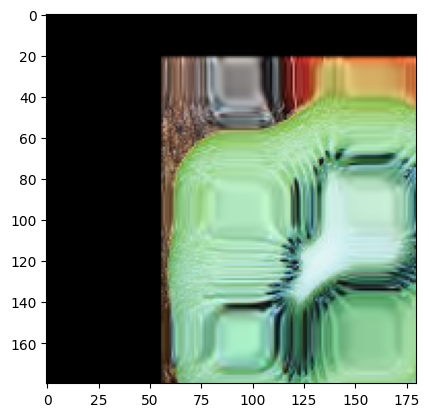

In [ ]:
# BT1 Chọn ảnh quả kiwi bất kì .
# Tịnh tiến quả kiwi 50 pixel sang phải và 30 pixel xuống dưới.
# Áp dụng hiệu ứng sóng (wave effect) lên quả kiwi bằng cách sử dụng biến đổi tọa độ (map_coordinates) với hàm sin.
# Lưu ảnh kết quả vào file kiwi_wave.jpg
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

data = iio.imread('./exercise/colorful-ripe-tropical-fruits.jpg')
# Chọn quả kiwi
kiwi = data[920:1100, 390:570]
print(data.shape)
# Tịnh tiến quả kiwi
bdata = nd.shift(kiwi, (30, 50, 0))

def GeoFun(outcoord):
    a = 10 * np.sin(outcoord[0]/10.0) + outcoord[0]
    b = 10 * np.sin(outcoord[1]/10.0) + outcoord[1]
    return a, b, outcoord[2]
# Áp dụng hiệu ứng sóng
kiwi_wave = nd.geometric_transform(bdata, GeoFun)
# Lưu ảnh kết quả
iio.imsave('kiwi_wave.jpg', kiwi_wave)

plt.imshow(kiwi_wave)
plt.show()

(1414, 2119, 3)


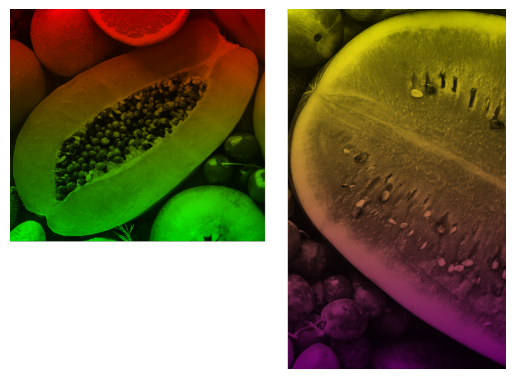

In [28]:
# BT2
# Chọn quả đu đủ và dưa hấu từ ảnh.
# Đổi màu đu đủ thành gradient từ đỏ sang xanh lá, và dưa hấu thành gradient từ vàng sang tím.
# Ghép hai quả lên một nền trong suốt (alpha channel) và lưu dưới dạng PNG.
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd
import random

data = iio.imread('./exercise/colorful-ripe-tropical-fruits.jpg')
print(data.shape)

# Đu đủ
dudu = data[310:820, 120:680].copy()
# Dưa hấu
duahau = data[310:1100, 1640:2119].copy()

# Gradient Color Transformation

def apply_gradient(image, start_color, end_color):
    """
    Applies a vertical gradient transformation to an image's color.
    image: NumPy array (height, width, 3)
    start_color: Tuple/list of (R, G, B) for the top of the image
    end_color: Tuple/list of (R, G, B) for the bottom of the image
    """
    height, width, _ = image.shape
    output_image = np.zeros_like(image, dtype=np.float32)

    for i in range(height):
        # Calculate the interpolation factor based on row position
        # Factor goes from 0 (top) to 1 (bottom)
        factor = i / (height - 1)

        # Interpolate each color channel
        r = start_color[0] * (1 - factor) + end_color[0] * factor
        g = start_color[1] * (1 - factor) + end_color[1] * factor
        b = start_color[2] * (1 - factor) + end_color[2] * factor

        output_image[i, :, 0] = r
        output_image[i, :, 1] = g
        output_image[i, :, 2] = b

    # Combine the original image's intensity with the new gradient color
    # This approach mixes the gradient colors with the existing brightness/texture.
    # We can use the grayscale intensity of the original image as a mask.
    gray_image = np.mean(image, axis=-1, keepdims=True) / 255.0 # Normalize to 0-1
    # Scale the gradient colors by the original image's intensity
    transformed_image = output_image * gray_image

    return np.clip(transformed_image, 0, 255).astype(np.uint8) # Clip and convert back to uint8

# Red: (255, 0, 0), Green: (0, 255, 0)
dudu_gradient = apply_gradient(dudu, (255, 0, 0), (0, 255, 0))

# Yellow: (255, 255, 0), Purple: (128, 0, 128)
duahau_gradient = apply_gradient(duahau, (255, 255, 0), (128, 0, 128))

# Create Transparent Background and Composite

# Determine the size of the canvas. Let's make it large enough to hold both fruits
# For simplicity, we'll place them side by side.
canvas_height = max(dudu_gradient.shape[0], duahau_gradient.shape[0])
canvas_width = dudu_gradient.shape[1] + duahau_gradient.shape[1] + 50

# Create a transparent background (RGBA)
# Initialize with fully transparent pixels (0,0,0,0)
transparent_canvas = np.zeros((canvas_height, canvas_width, 4), dtype=np.uint8)

# Function to blend an image with alpha onto the canvas
def place_on_canvas(canvas, image, x_offset, y_offset):
    h, w, _ = image.shape
    # Create a mask from the image (e.g., non-black pixels are opaque)
    # A simple mask for alpha channel could be based on intensity,
    # or you could assume the fruit itself is opaque.
    # For now, let's assume the fruit area is fully opaque (alpha = 255).
    image_rgba = np.concatenate((image, np.full((h, w, 1), 255, dtype=np.uint8)), axis=-1)

    # Calculate the region on the canvas where the image will be placed
    canvas_region = canvas[y_offset : y_offset + h, x_offset : x_offset + w]

    # Simple alpha blending: just copy if the image itself is opaque.
    # If the fruit has irregular shapes, a more sophisticated masking would be needed.
    # For this exercise, we assume the extracted fruit area is solid.
    canvas[y_offset : y_offset + h, x_offset : x_offset + w] = image_rgba

    return canvas

# Place papaya on the left
transparent_canvas = place_on_canvas(transparent_canvas, dudu_gradient, 0, 0)

# Place watermelon to the right of papaya with some padding
transparent_canvas = place_on_canvas(transparent_canvas, duahau_gradient, dudu_gradient.shape[1] + 50, 0)

# Save the result
iio.imsave('fruits_gradient_transparent.png', transparent_canvas)

# Display the result
plt.imshow(transparent_canvas)
plt.axis('off')
plt.show()

(605, 1021, 3)


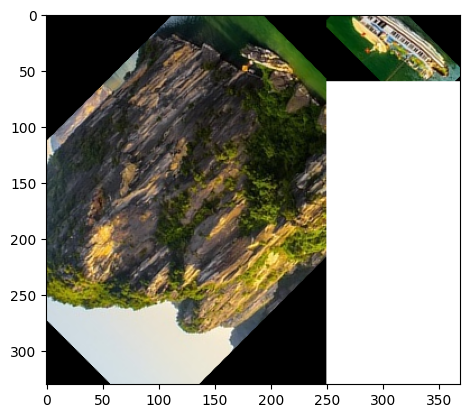

In [ ]:
# BT3 Chọn ảnh núi và thuyền .
# Xoay cả hai đối tượng 45 độ, giữ kích thước ban đầu (reshape=False).
# Tạo hiệu ứng phản chiếu dọc (vertical mirror) cho cả hai đối tượng sau khi xoay.
# Ghép cả hai đối tượng lên một canvas trắng và lưu vào mountain_boat_mirror.jpg
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Đọc ảnh
data = iio.imread('./exercise/quang_ninh.jpg')
print(data.shape)

# Cắt ảnh núi và thuyền
nui = data[10:340, 420:670]
thuyen = data[340:400, 550:670]

# Hàm xoay ảnh
def rotate_image(image, angle):
    return nd.rotate(image, angle, reshape=False)

# Xoay cả hai đối tượng 45 độ
nui_rotated = rotate_image(nui, 45)
thuyen_rotated = rotate_image(thuyen, 45)

# Tạo hiệu ứng phản chiếu dọc
def vertical_mirror(image):
    return np.flipud(image)

nui_mirrored = vertical_mirror(nui_rotated)
thuyen_mirrored = vertical_mirror(thuyen_rotated)

# Tạo canvas trắng
canvas_height = max(nui_mirrored.shape[0], thuyen_mirrored.shape[0])
canvas_width = nui_mirrored.shape[1] + thuyen_mirrored.shape[1]
canvas = np.ones((canvas_height, canvas_width, 3), dtype=np.uint8) * 255  # Canvas trắng

# Ghép núi và thuyền vào canvas
canvas[:nui_mirrored.shape[0], :nui_mirrored.shape[1]] = nui_mirrored
canvas[:thuyen_mirrored.shape[0], nui_mirrored.shape[1]:] = thuyen_mirrored

# Lưu ảnh vào file
iio.imwrite('./mountain_boat_mirror.jpg', canvas)
plt.imshow(canvas)
plt.show()


(348, 600, 3)


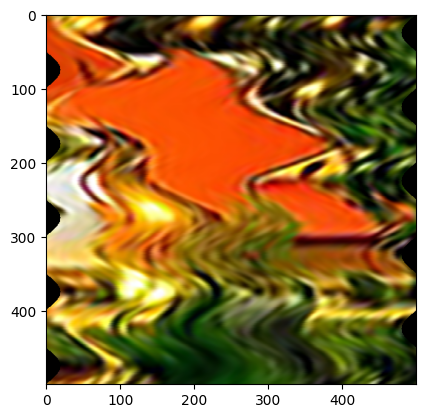

In [ ]:
# BT4 Chọn ngôi chùa bất kì.
# Phóng to ngôi chùa lên 5 lần.
# Áp dụng một biến đổi hình học tùy chỉnh (geometric transform) để tạo hiệu ứng "uốn cong" (warping) ngôi chùa.
# Lưu ảnh kết quả vào pagoda_warped.jpg.
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Đọc ảnh
data = iio.imread('./exercise/pagoda.jpg')
print(data.shape)

# Cắt ảnh ngôi chùa
chua = data[180:280, 400:500]

# Phóng to ngôi chùa lên 5 lần
chua_zoomed = nd.zoom(chua, (5, 5, 1))

# Hàm tạo hiệu ứng "uốn cong"
def warp_image(image):
    rows, cols = image.shape[:2]
    
    # Tạo lưới tọa độ cho biến đổi
    x = np.arange(cols)
    y = np.arange(rows)
    x, y = np.meshgrid(x, y)

    # Tạo biến đổi hình học
    warp_x = x + 20 * np.sin(2 * np.pi * y / 100)  # Uốn cong theo chiều dọc
    warp_y = y

    # Áp dụng biến đổi
    warped_image = np.zeros_like(image)
    for i in range(rows):
        for j in range(cols):
            new_x = int(warp_x[i, j])
            new_y = int(warp_y[i, j])
            if 0 <= new_x < cols and 0 <= new_y < rows:
                warped_image[i, j] = image[new_y, new_x]

    return warped_image

# Áp dụng biến đổi hình học để tạo hiệu ứng "uốn cong"
chua_warped = warp_image(chua_zoomed)

# Lưu ảnh kết quả vào file
iio.imwrite('./pagoda_warped.jpg', chua_warped.astype(np.uint8))

plt.imshow(chua_warped)
plt.show()


Chọn ảnh:
1: ./exercise/colorful-ripe-tropical-fruits.jpg
2: ./exercise/ha-long-bay-in-vietnam.jpg
3: ./exercise/pagoda.jpg


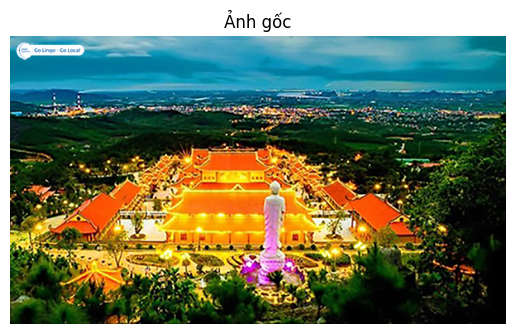


Chọn phép biến đổi:
1: Tịnh tiến
2: Xoay
3: Phóng to/thu nhỏ
4: Làm mờ Gaussian
5: Biến đổi sóng
6: Thoát


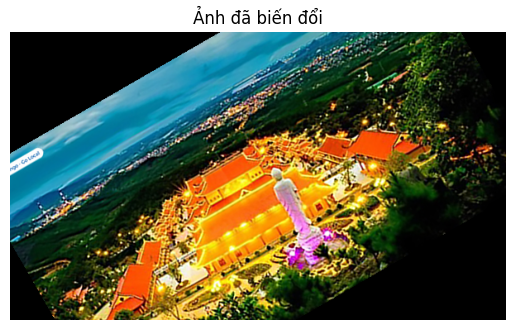


Chọn phép biến đổi:
1: Tịnh tiến
2: Xoay
3: Phóng to/thu nhỏ
4: Làm mờ Gaussian
5: Biến đổi sóng
6: Thoát


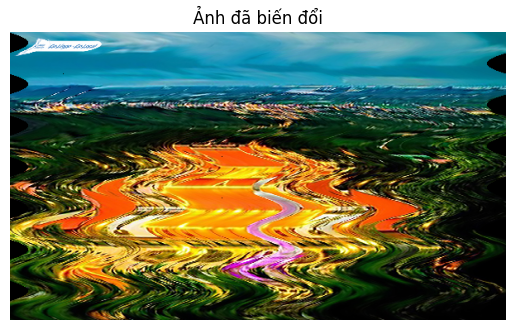


Chọn phép biến đổi:
1: Tịnh tiến
2: Xoay
3: Phóng to/thu nhỏ
4: Làm mờ Gaussian
5: Biến đổi sóng
6: Thoát


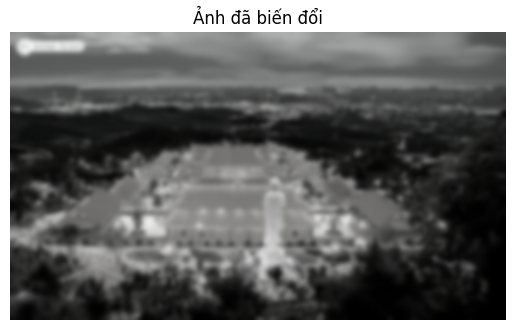


Chọn phép biến đổi:
1: Tịnh tiến
2: Xoay
3: Phóng to/thu nhỏ
4: Làm mờ Gaussian
5: Biến đổi sóng
6: Thoát


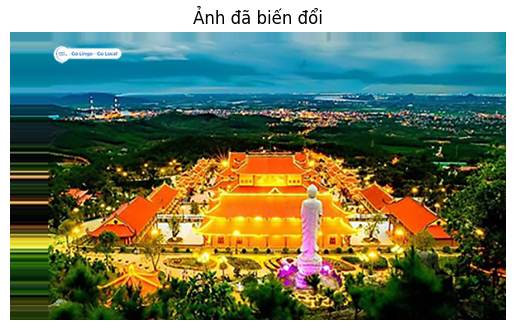


Chọn phép biến đổi:
1: Tịnh tiến
2: Xoay
3: Phóng to/thu nhỏ
4: Làm mờ Gaussian
5: Biến đổi sóng
6: Thoát
Thoát chương trình.


In [ ]:
# BT5 Tạo một chương trình menu tương tác cho phép người dùng chọn các phép biến đổi sau:
# Tịnh tiến (hỏi số pixel di chuyển theo x và y).
# Xoay (hỏi góc xoay và chọn reshape=True/False).
# Phóng to/thu nhỏ (hỏi hệ số zoom).
# Làm mờ Gaussian (hỏi giá trị sigma).
# Biến đổi sóng (hỏi biên độ sóng).
# Người dùng chọn ảnh từ 3 ảnh bất kì
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Hàm để hiển thị ảnh
def show_image(image, title='Image'):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hàm tịnh tiến
def translate_image(image, tx, ty):
    return nd.shift(image, shift=(ty, tx, 0), mode='nearest')

# Hàm xoay
def rotate_image(image, angle, reshape):
    return nd.rotate(image, angle, reshape=reshape)

# Hàm phóng to/thu nhỏ
def zoom_image(image, zoom_factor):
    return nd.zoom(image, zoom_factor)

# Hàm làm mờ Gaussian
def gaussian_blur(image, sigma):
    return nd.gaussian_filter(image, sigma=sigma)

# Hàm biến đổi sóng
def wave_transform(image, amplitude):
    rows, cols = image.shape[:2]
    x = np.arange(cols)
    y = np.arange(rows)
    x, y = np.meshgrid(x, y)
    wave_x = amplitude * np.sin(2 * np.pi * y / 50)  # Biến đổi sóng
    warped_image = np.zeros_like(image)
    
    for i in range(rows):
        for j in range(cols):
            new_x = int(j + wave_x[i, j])
            new_y = i
            if 0 <= new_x < cols:
                warped_image[i, new_x] = image[i, j]
    
    return warped_image

# Chọn ảnh
images = ['./exercise/colorful-ripe-tropical-fruits.jpg', './exercise/ha-long-bay-in-vietnam.jpg', './exercise/pagoda.jpg']
print("Chọn ảnh:")
for i, img_path in enumerate(images):
    print(f"{i + 1}: {img_path}")

choice = int(input("Nhập số tương ứng với ảnh bạn muốn chọn (1-3): ")) - 1
image = iio.imread(images[choice])
show_image(image, "Ảnh gốc")

# Menu tương tác
while True:
    print("\nChọn phép biến đổi:")
    print("1: Tịnh tiến")
    print("2: Xoay")
    print("3: Phóng to/thu nhỏ")
    print("4: Làm mờ Gaussian")
    print("5: Biến đổi sóng")
    print("6: Thoát")

    option = int(input("Nhập số tương ứng với phép biến đổi (1-6): "))

    if option == 1:
        tx = int(input("Nhập số pixel di chuyển theo trục x: "))
        ty = int(input("Nhập số pixel di chuyển theo trục y: "))
        transformed_image = translate_image(image, tx, ty)

    elif option == 2:
        angle = float(input("Nhập góc xoay (độ): "))
        reshape = input("Có muốn thay đổi kích thước không? (Yes/No): ").strip().lower() == 'yes'
        transformed_image = rotate_image(image, angle, reshape)

    elif option == 3:
        zoom_factor = float(input("Nhập hệ số zoom (ví dụ: 2.0 để phóng to, 0.5 để thu nhỏ): "))
        transformed_image = zoom_image(image, zoom_factor)

    elif option == 4:
        sigma = float(input("Nhập giá trị sigma cho làm mờ Gaussian: "))
        transformed_image = gaussian_blur(image, sigma)

    elif option == 5:
        amplitude = float(input("Nhập biên độ sóng: "))
        transformed_image = wave_transform(image, amplitude)

    elif option == 6:
        print("Thoát chương trình.")
        break

    else:
        print("Lựa chọn không hợp lệ. Vui lòng thử lại.")
        continue

    # Hiển thị ảnh đã biến đổi
    show_image(transformed_image, "Ảnh đã biến đổi")
